In [9]:
import pandas as pd
import matplotlib.pyplot as plt

Stratified sampling for splitting a dataset alleviates the problem of Random Sampling in datasets with an imbalanced-class distribution. Here, the distribution of classes in each of the train, validation, and test sets is preserved.

Suppose a dataset consists of 1000 images, of which 600 are dog images and 400 are cat images. In that case, stratified sampling ensures that 60% of the images are of category “dog” and 40% are of category “cat” in the training and validation sets. That is, if a train-validation split of 80%-20% is desired, out of the 800 images in the training set, 480 images (60%) will be of dogs, and the rest 320 (40%) will be of cats.

In this dataset, there are 7 types of lesions
'Melanocytic nevi','Melanoma','Benign keratosis-like lesions ','Basal cell carcinoma', 'Actinic keratoses', 'Vascular lesions', 'Dermatofibroma'

In [10]:
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions ',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

1. Run the code found at `notebooks\kaggle_dataset_downloader`
2. Navigate to your chosen download folder for the kmader dataset, and find `HAM10000_metadata.csv` in the `metadata` subfolder
3. Copy the file path, and replace the hyperparameter shown below

In [11]:
HAM10000_DATASET_PATH = r"C:\Users\colwy\Documents\SFU\Spring2025\CMPT 419\Project\2025_1_project_06\dataset\kmader\metadata\HAM10000_metadata.csv"

The only null values are found in the 'age' column, remove those entries from the dataset

In [12]:
metadata_df = pd.read_csv(HAM10000_DATASET_PATH)

print(metadata_df.head(), '\n')

#Show null values per column
print(metadata_df.isnull().sum(), '\n')

#Replace null values with the mean
metadata_df['age'].fillna(int(metadata_df['age'].mean()),inplace=True)

print(metadata_df.isnull().sum())

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear 

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64 

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dtype: int64


C:\Users\colwy\AppData\Local\Temp\ipykernel_30352\3356220225.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  metadata_df['age'].fillna(int(metadata_df['age'].mean()),inplace=True)


Use a histogram to show the proportion of each lesion type in the database

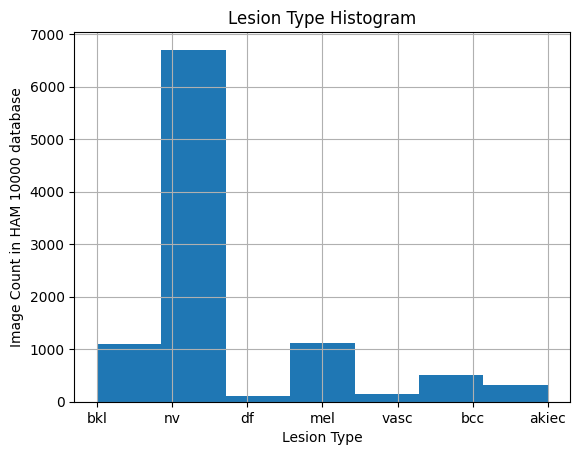

Melanocytic nevi image count: 6705, dataset percentage: 66.95%
Melanoma image count: 1113, dataset percentage: 11.11%
Benign keratosis-like lesions  image count: 1099, dataset percentage: 10.97%
Basal cell carcinoma image count: 514, dataset percentage: 5.13%
Actinic keratoses image count: 327, dataset percentage: 3.27%
Vascular lesions image count: 142, dataset percentage: 1.42%
Dermatofibroma image count: 115, dataset percentage: 1.15%


In [28]:
# Visualize the distribution of lesion images with a histogram
def visualize_dataframe_column_as_histogram(df):
    lesion_histogram = df['dx'].hist(bins=7)
    lesion_histogram.set_title("Lesion Type Histogram")
    lesion_histogram.set_xlabel("Lesion Type")
    lesion_histogram.set_ylabel("Image Count in HAM 10000 database")
    plt.show()

visualize_dataframe_column_as_histogram(metadata_df)
total_count = len(metadata_df)

# Print the exact values
for key, val in lesion_type_dict.items():
    temp_count = metadata_df.loc[metadata_df['dx'] == key, 'dx'].count()
    print(f"{val} image count: {temp_count}, dataset percentage: {round((temp_count / total_count)*100, 2)}%")

Melanocytic Nevi
- Typically symmetrical with smooth, well-defined borders.
- Uniform pigmentation (often brown or black), though may vary slightly with age.

✅ Benign

2. Melanoma
- Asymmetrical with irregular borders and uneven color distribution (can include black, brown, red, white, or blue).
- Tends to grow or change over time in size, shape, or color.

❌ Malignant

3. Benign Keratosis-like Lesions
- Waxy, scaly, or crusty appearance—can resemble warts or be mistaken for melanoma.
- Often raised and may have a “stuck-on” look.

✅ Benign

4. Basal Cell Carcinoma
- Pearly or waxy bump, often with visible blood vessels; may ulcerate in the center.
- Slow-growing but invasive if untreated, commonly on sun-exposed skin.

❌ Malignant

5. Actinic Keratoses
- Rough, scaly patches that may be pink, red, or brown—often on sun-damaged skin.
- Can be a precursor to squamous cell carcinoma.

⚠️ Pre-malignant

6. Vascular Lesions
- Appear red, purple, or blue due to abnormal blood vessels (e.g., hemangiomas, angiomas).
- Typically soft and compressible, often present at birth or develop early in life.

✅ Benign

7. Dermatofibroma
- Firm, raised nodules—may appear pink or brown and dimple inward when pinched.
- Usually small and non-changing, often on the legs or arms.

✅ Benign

Plan: Use stratified splitting with an 80/10/10 training/validation/testing set

This ensures that the distribution of lesion types across sets is balanced



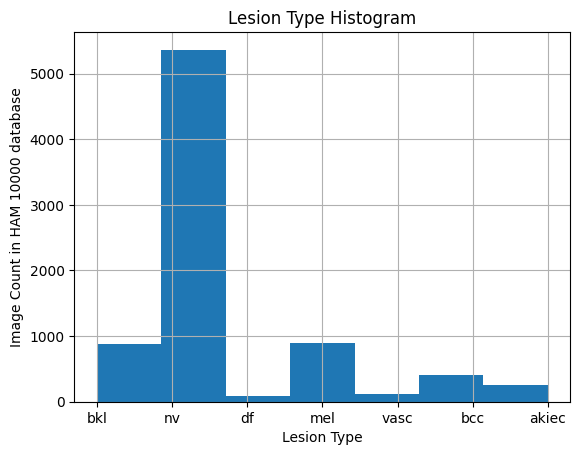

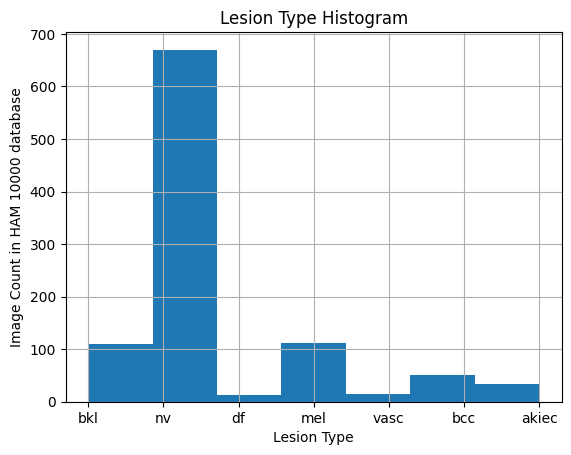

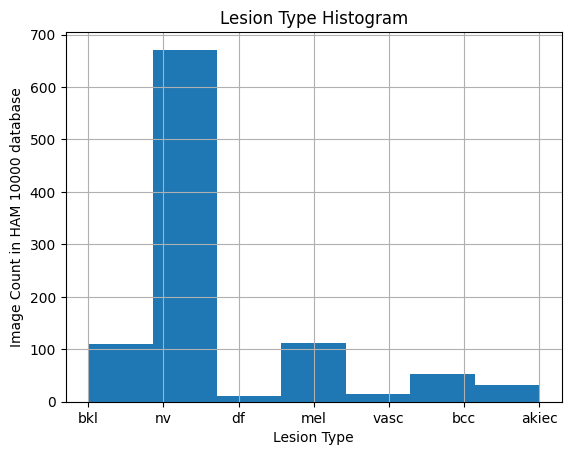

In [37]:
def get_stratified_sampling_df(df, stratify_by, split_ratios=[0.8, 0.1, 0.1]):
    """
    Splits a DataFrame into stratified subsets based on class distribution.

    Parameters:
        df (pd.DataFrame): The input DataFrame to split.
        stratify_by (str): Column name to stratify by.
        split_ratios (tuple): A tuple of n floats such as (train, val, test) or (train, test) that must sum to 1.0.

    Returns:
        tuple: (length based on # of split percentages passed)
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError("`dataframe` must be a pandas DataFrame.")
    
    if not stratify_by:
        raise ValueError("`stratified_column_key` must not be empty.")
    if stratify_by not in df.columns:
        raise KeyError(f"`{stratify_by}` is not a column in the dataframe.")
    
    if sum(split_ratios) != 1.0:
        raise ValueError(f"`split_percentages` must sum to 1.0 (currently sums to {sum(split_ratios)})")

    # Setup
    classes = df[stratify_by].unique()
    splits = [[] for _ in split_ratios]

    for label in classes:
        # Sample randomly in order to shuffle any implicit sorting done by the dataset
        df_subset = df.loc[df[stratify_by] == label].sample(frac=1, random_state=42)

        # Partition the dataframe based on the split ratios
        total = len(df_subset)
        start = 0
        for idx, percentage in enumerate(split_ratios):
            end = total if idx == len(split_ratios) - 1 else start + round(total * percentage)
            splits[idx].append(df_subset.iloc[start:end])
            start = end 
    
    final_splits = []
    for partition in splits:
        final_splits.append(pd.concat(partition).reset_index(drop=True))

    return final_splits


train_df, validate_df, test_df = get_stratified_sampling_df(
    df=metadata_df, 
    stratify_by='dx', 
    split_ratios=[0.8,0.1,0.1])

visualize_dataframe_column_as_histogram(train_df)
visualize_dataframe_column_as_histogram(validate_df)
visualize_dataframe_column_as_histogram(test_df)